# Setup

In [92]:
import logging

logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s [%(levelname)s] %(module)s.%(funcName)s(): %(message)s"
)
logger = logging.getLogger(__name__)

import matplotlib.pyplot as plt
import numpy as np

from typing import Optional, List
from matplotlib.lines import Line2D

from fjsspw_solver import Individual, Encoding
from fjsspw_solver.genetic_algorithm import Method, MethodParams, Crossovers

from util.benchmark_parser import WorkerBenchmarkParser
from util.uncertainty import create_uncertainty_vector
from util.graph import Graph

PROD = False

In [93]:
parser = WorkerBenchmarkParser()
instance_name = 'Fattahi10.fjs'
encoding = parser.parse_benchmark(f'instances/Example_Instances_FJSSP-WF/{instance_name}')

In [94]:
encoding = Encoding(encoding.durations(), encoding.job_sequence())
method_params = MethodParams(
    epochs=10,
    population_size=10,
    crossover=Crossovers.POX
)

In [95]:
uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)

In [96]:
def uncertain_eval_function(indv: Individual, iters: int = 1) -> List|float:
    _, machines, workers, start_times, end_times = indv.get_representation()
    logger.debug(f"machines={machines}"
                 f", workers={workers}"
                 f", job_sequence={encoding.get_job_sequence()}"
                 f", start_times={start_times}"
                 f", end_times={end_times}")
    fitnesses = [0] * iters
    for i in range(iters):
        g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
        g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
        fitnesses[i] = max(g.e)
    return fitnesses if iters > 1 else fitnesses[0]

# Run method

In [97]:
logger.info("Init method")
method = Method(method_params, encoding, uncertain_eval_function)
logger.info("Finish init method")

In [98]:
method.solve()

# Evaluate and plot results

In [99]:
best_indv = method.best_indv

In [100]:
sequence, machines, workers, start_times, end_times = best_indv.get_representation()
sequence, machines, workers, start_times, end_times

([1, 3, 3, 2, 3, 1, 2, 2, 0, 0, 0, 1],
 [0, 1, 4, 0, 1, 4, 1, 2, 4, 0, 4, 2],
 [3, 2, 3, 2, 2, 6, 0, 0, 2, 0, 1, 4],
 [309, 591, 720, 0, 230, 885, 0, 56, 486, 230, 309, 486],
 [468, 720, 885, 230, 298, 1049, 56, 230, 591, 309, 486, 621])

In [101]:
if PROD:
    assert len(sequence) > 0, "The sequence should not be empty."
    assert len(machines) > 0, "The number of machines should not be empty."
    assert len(workers) > 0, "The number of workers should not be empty."
    assert len(start_times) > 0, "The number of start_times should not be empty."
    assert len(end_times) > 0, "The number of end_times should not be empty."

In [102]:
# start_times, machines, workers = evaluation.translate(sequence, machines, workers, encoding.get_durations()) # necessary because the solver does not provide the start times of the schedule
# c = evaluation.makespan(start_times, machines, workers, encoding.get_durations())
c = best_indv.get_internal_fitness()
robust_c = uncertain_eval_function(best_indv)
print(f'Makespan: {c}')
print(f'Robust makespan: {robust_c}')

Makespan: 1049
Robust makespan: 2206.40676302433


In [107]:
def plot_fjsspw_gantt(
    job_sequence: list[int],
    machines: list[int],
    workers: list[int],
    start_times: list[float|int],
    end_times: list[float|int],
    instance_name: str = "FJSSP-W",
    c: Optional[float] = None,
    robust_c: Optional[float] = None,
):
    """
    Visualizes the FJSSP-W schedule.
    
    Args:
        job_sequence: list of job IDs for each operation index (e.g. [0, 0, 1, 1])
        machines: machine assigned to each operation index
        workers: worker assigned to each operation index
        start_times: start time for each operation index
        end_times: end time for each operation index
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Setup Colors (One unique color per Job)
    unique_jobs = list(set(job_sequence))
    colors = plt.get_cmap('Set3', len(unique_jobs))
    job_color_map = {job: colors(i) for i, job in enumerate(unique_jobs)}

    # Plotting the bars
    num_ops = len(job_sequence)
    unique_machines = list(range(len(encoding.get_durations()[0])))
    
    job_counts = [0] * len(unique_jobs)
    for i in range(num_ops):
        job_id = job_sequence[i]
        op_id = job_counts[job_id]
        job_counts[job_id] += 1
        global_idx = encoding.get_operation_index(job_id, op_id)
        start_time = start_times[global_idx]
        end_time = end_times[global_idx]
        duration = end_time - start_time
        worker_id = workers[global_idx]
        m_id = machines[global_idx]
        
        # Draw the bar
        ax.broken_barh([(start_time, duration)], 
                       (m_id - 0.4, 0.8), 
                       facecolors=job_color_map[job_id], 
                       edgecolor='black', 
                       alpha=0.8)
        
        # Add the label
        label = f"J{job_id} O{op_id} - W{worker_id}\nT={duration}"
        ax.text(start_time + duration/2, m_id, label, 
                ha='center', va='center', fontsize=12)

    # Formatting the Chart
    ax.set_xlabel('Time')
    ax.set_ylabel('Machine ID')
    title = f'{instance_name}'
    if c or robust_c:
        title += " - "
        title += f"{c} " if c else "??"
        title += " / " if c and robust_c else " "
        title += f"{robust_c:.2f}" if robust_c else "??"
        if c and robust_c:
            title += f", R={robust_c/c:.4f}"
    ax.set_title(title)
    
    ax.set_yticks(unique_machines)
    ax.set_yticklabels([f'Machine {m}' for m in unique_machines])
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)

    # Add a legend for Jobs
    legend_elements = [Line2D([0], [0], color=job_color_map[j], lw=4, label=f'Job {j}') for j in unique_jobs]
    ax.legend(handles=legend_elements, loc='upper right', title="Jobs")

    plt.tight_layout()
    plt.show()

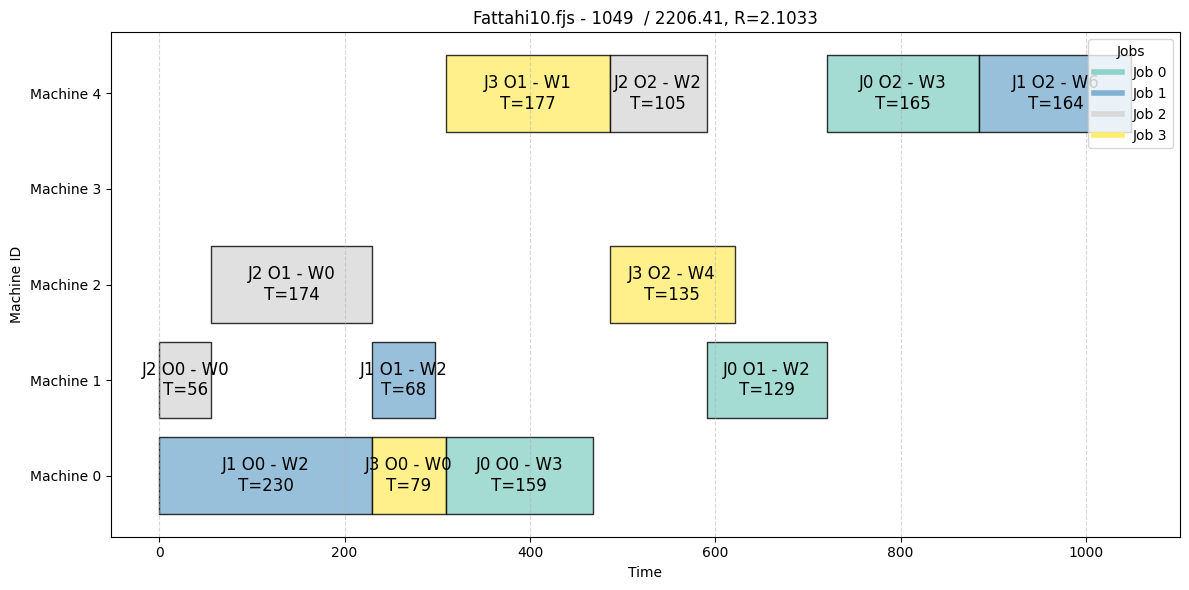

In [108]:
plot_fjsspw_gantt(sequence, machines, workers, start_times, end_times, instance_name=instance_name, c=c, robust_c=robust_c)